# Source code for Emma Sims

### 1. Library import. Preparation stage

In [203]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
    balanced_accuracy_score, classification_report
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone

from xgboost import XGBClassifier
import shap

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

RANDOM_STATE = 42

### 2. Loading dataset and defining the objective

In [204]:
df = pd.read_csv("Bankruptcy.csv")
df.head(10)

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,0,0.434456,0.481247,0.498742,0.596326,0.596326,0.998791,0.797012,0.809041,0.303237,0.781291,2.217908e-04,3.040000e+09,0.473117,0.000000,0.000000,0.174076,0.174076,0.174076,0.202515,0.320153,0.009755,0.087452,0.156963,0.021977,0.842429,0.685817,0.685817,0.217409,5.620000e+09,0.000419,0.263370,0.379056,0.016739,0.014061,0.630611,0.001595,0.043807,0.956193,0.005102,0.369637,0.007023,0.087466,0.155991,0.395832,0.065967,0.000781,0.008093,2.967364e-04,5.900000e+09,0.017419,0.004304,0.389498,0.009512,0.787113,0.185681,0.204108,0.046863,0.014760,0.010498,0.023262,0.357598,0.277073,0.005461,0.472822,0.733696,0.326899,0.000000,0.922162,0.002054,0.029762,1.104112e-04,1.054056e-04,0.593969,7.230000e+09,0.671572,0.624778,0.472822,0.326899,0.110933,0.642917,0.459268,0.590226,0.314565,0.017526,0,0.765336,0.001373,0.626305,0.596326,0.838369,0.275936,0.026791,0.565157,1,0.087378
1,0,0.542534,0.571413,0.590663,0.603417,0.603417,0.999041,0.797476,0.809375,0.303526,0.781638,8.550000e+09,1.550000e+09,0.467422,0.000264,0.251645,0.189078,0.189078,0.189078,0.232107,0.329561,0.053753,0.115300,0.188522,0.022079,0.848008,0.689377,0.689377,0.217591,6.220000e+09,0.000466,0.263868,0.385297,0.009777,0.005425,0.631052,0.007164,0.130000,0.870000,0.005211,0.376524,0.005366,0.115280,0.187588,0.404142,0.193403,0.001051,0.006012,1.282100e-04,2.63

In [205]:
df.shape

(4091, 96)

In [206]:
df.columns = [col.strip() for col in df.columns]
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,0,0.434456,0.481247,0.498742,0.596326,0.596326,0.998791,0.797012,0.809041,0.303237,0.781291,2.217908e-04,3.040000e+09,0.473117,0.000000,0.000000,0.174076,0.174076,0.174076,0.202515,0.320153,0.009755,0.087452,0.156963,0.021977,0.842429,0.685817,0.685817,0.217409,5.620000e+09,0.000419,0.263370,0.379056,0.016739,0.014061,0.630611,0.001595,0.043807,0.956193,0.005102,0.369637,0.007023,0.087466,0.155991,0.395832,0.065967,0.000781,0.008093,2.967364e-04,5.900000e+09,0.017419,0.004304,0.389498,0.009512,0.787113,0.185681,0.204108,0.046863,0.014760,0.010498,0.023262,0.357598,0.277073,0.005461,0.472822,0.733696,0.326899,0.000000,0.922162,0.002054,0.029762,1.104112e-04,1.054056e-04,0.593969,7.230000e+09,0.671572,0.624778,0.472822,0.326899,0.110933,0.642917,0.459268,0.590226,0.314565,0.017526,0,0.765336,0.001373,0.626305,0.596326,0.838369,0.275936,0.026791,0.565157,1,0.087378
1,0,0.542534,0.571413,0.590663,0.603417,0.603417,0.999041,0.797476,0.809375,0.303526,0.781638,8.550000e+09,1.550000e+09,0.467422,0.000264,0.251645,0.189078,0.189078,0.189078,0.232107,0.329561,0.053753,0.115300,0.188522,0.022079,0.848008,0.689377,0.689377,0.217591,6.220000e+09,0.000466,0.263868,0.385297,0.009777,0.005425,0.631052,0.007164,0.130000,0.870000,0.005211,0.376524,0.005366,0.115280,0.187588,0.404142,0.193403,0.001051,0.006012,1.282100e-04,2.63

### The main objectives of this case study are:
 * Develoving logistic regression that will be used as a benchmark
 * Comparing this benchmark model with more advanced model that will be created later on
 * Identifying important financial factors and showing their impact on bankruptcy

### 3. EDA

#### 3.1 Missing values, duplicates, data types

In [207]:
df.dtypes

Bankrupt?                                                    int64
ROA(C) before interest and depreciation before interest    float64
ROA(A) before interest and % after tax                     float64
ROA(B) before interest and depreciation after tax          float64
Operating Gross Margin                                     float64
Realized Sales Gross Margin                                float64
Operating Profit Rate                                      float64
Pre-tax net Interest Rate                                  float64
After-tax net Interest Rate                                float64
Non-industry income and expenditure/revenue                float64
Continuous interest rate (after tax)                       float64
Operating Expense Rate                                     float64
Research and development expense rate                      float64
Cash flow rate                                             float64
Interest-bearing debt interest rate                        flo

In [208]:
df.isna().sum().sort_values()

Bankrupt?                                                  0
Total income/Total expense                                 0
Retained Earnings to Total Assets                          0
Long-term Liability to Current Assets                      0
Current Liabilities/Equity                                 0
Working Capital/Equity                                     0
Current Liabilities/Liability                              0
Inventory/Current Liability                                0
Inventory/Working Capital                                  0
Operating Funds to Liability                               0
Total expense/Assets                                       0
Current Liability to Assets                                0
Quick Assets/Current Liability                             0
Cash/Total Assets                                          0
Current Assets/Total Assets                                0
Quick Assets/Total Assets                                  0
Working Capital to Total

In [209]:
df.duplicated().sum()

np.int64(0)

In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4091 entries, 0 to 4090
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                4091 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  4091 non-null   float64
 2   ROA(A) before interest and % after tax                   4091 non-null   float64
 3   ROA(B) before interest and depreciation after tax        4091 non-null   float64
 4   Operating Gross Margin                                   4091 non-null   float64
 5   Realized Sales Gross Margin                              4091 non-null   float64
 6   Operating Profit Rate                                    4091 non-null   float64
 7   Pre-tax net Interest Rate                                4091 non-null   float64
 8   After-tax net Interest Rate 

#### 3.2 Class imbalance check

In [211]:
target_proportion = df["Bankrupt?"].value_counts(normalize=True).sort_index() * 100

In [212]:
target_proportion

Bankrupt?
0    96.920068
1     3.079932
Name: proportion, dtype: float64

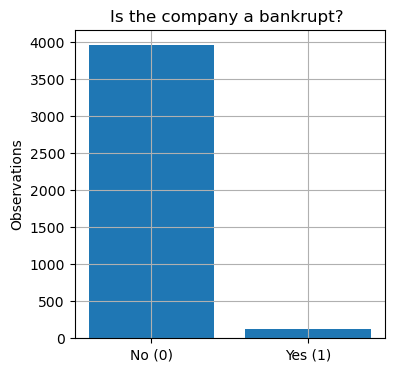

In [213]:
plt.figure(figsize = (4, 4))
plt.bar(["No (0)", "Yes (1)"], df['Bankrupt?'].value_counts().sort_index().values)
plt.title("Is the company a bankrupt? ")
plt.ylabel("Observations")
plt.savefig(r"C:\Users\alnur\Desktop\My life\ML Engineer\imbalance")
plt.show()

#### 3.3 Separate features and target

In [214]:
target_col = "Bankrupt?"

In [215]:
X = df.drop(columns = [target_col]).copy()
y = df[target_col].copy()
X.shape[1]

95

In [216]:
constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
constant_cols

['Net Income Flag']

In [217]:
df["Net Income Flag"].value_counts() # delete this column, cuz contains no predictive info 

Net Income Flag
1    4091
Name: count, dtype: int64

In [218]:
X = X.drop(columns = ["Net Income Flag"])

In [219]:
X.shape

(4091, 94)

In [220]:
desc = X.describe().T
desc

,count,mean,std,min,25%,50%,75%,max
ROA(C) before interest and depreciation before interest,4091.0,5.046019e-01,5.948289e-02,0.024277,4.765271e-01,5.023644e-01,5.346122e-01,1.000000e+00
ROA(A) before interest and % after tax,4091.0,5.582323e-01,6.512663e-02,0.000000,5.350796e-01,5.596380e-01,5.881487e-01,9.847362e-01
ROA(B) before interest and depreciation after tax,4091.0,5.531417e-01,6.056486e-02,0.033514,5.274372e-01,5.519032e-01,5.837036e-01,9.577601e-01
Operating Gross Margin,4091.0,6.079872e-01,1.541270e-02,0.156308,6.004807e-01,6.061200e-01,6.139322e-01,6.651508e-01
Realized Sales Gross Margin,4091.0,6.079674e-01,1.539084e-02,0.156308,6.004807e-01,6.060768e-01,6.138601e-01,6.660229e-01
Operating Profit Rate,4091.0,9.986301e-01,1.676430e-02,0.000000,9.989688e-01,9.990222e-01,9.990927e-01,1.000000e+00
Pre-tax net Interest Rate,4091.0,7.970512e-01,1.599650e-02,0.000000,7.973854e-01,7.974610e-01,7.975784e-01,8.128485e-01
After-tax net Interest Rate,4091.0,8.089425e-01,1.701634e-02,0.000000,8.093113e-01,8.093744e-01,8.094691e-01,8.225510e-01
Non-industry income and expenditure/revenue,4091.0,3.036424e-01,1.192491e-02,0.000000,3.034651e-01,3.035260e-01,3.035845e-01,1.000000e+00
Continuous interest rate (after tax),4091.0,7.812299e-01,1.590744e-02,0.000000,7.815663e-01,7.816345e-01,7.817336e-01,7.959123e-01


#### 3.4 Correlation of all features against target value / checking multicollinearity 

In [221]:
corr_with_target = pd.concat([X, y], axis=1).corr(numeric_only = True)["Bankrupt?"].drop("Bankrupt?")
corr_with_target_abs = corr_with_target.abs().sort_values(ascending=False)

top_corr = corr_with_target_abs
top_corr

Net Income to Total Assets                                 0.330543
ROA(A) before interest and % after tax                     0.300371
ROA(B) before interest and depreciation after tax          0.284149
ROA(C) before interest and depreciation before interest    0.269698
Net worth/Assets                                           0.266575
Debt ratio %                                               0.266575
Retained Earnings to Total Assets                          0.219850
Persistent EPS in the Last Four Seasons                    0.218794
Liability-Assets Flag                                      0.214989
Current Liability to Assets                                0.206973
Net profit before tax/Paid-in capital                      0.204494
Working Capital to Total Assets                            0.201525
Per Share Net profit before tax (Yuan ¥)                   0.200411
Current Liability to Current Assets                        0.184084
Net Income to Stockholder's Equity              

In [222]:
top_features_for_eda = top_corr.index[:5].tolist()
top_features_for_eda

['Net Income to Total Assets',
 'ROA(A) before interest and % after tax',
 'ROA(B) before interest and depreciation after tax',
 'ROA(C) before interest and depreciation before interest',
 'Net worth/Assets']

In [223]:
corr_matrix = X.corr(numeric_only=True).abs()

In [224]:
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2", 0: "Correlation"})
)

high_corr_pairs = high_corr_pairs[high_corr_pairs["Correlation"] > 0.90].sort_values(by = "Correlation", ascending = False)

high_corr_pairs

,Feature_1,Feature_2,Correlation
3918,Current Liabilities/Liability,Current Liability to Liability,1.000000
3976,Current Liabilities/Equity,Current Liability to Equity,1.000000
2718,Debt ratio %,Net worth/Assets,1.000000
1684,Revenue Per Share (Yuan ¥),Total debt/Total net worth,1.000000
360,Operating Gross Margin,Gross Profit to Sales,1.000000
1368,Net Value Per Share (A),Net Value Per Share (C),0.999810
276,Operating Gross Margin,Realized Sales Gross Margin,0.999456
449,Realized Sales Gross Margin,Gross Profit to Sales,0.999456
1762,Operating Profit Per Share (Yuan ¥),Operating profit/Paid-in capital,0.999305
545,Pre-tax net Interest Rate,Continuous interest rate (after tax),0.999267


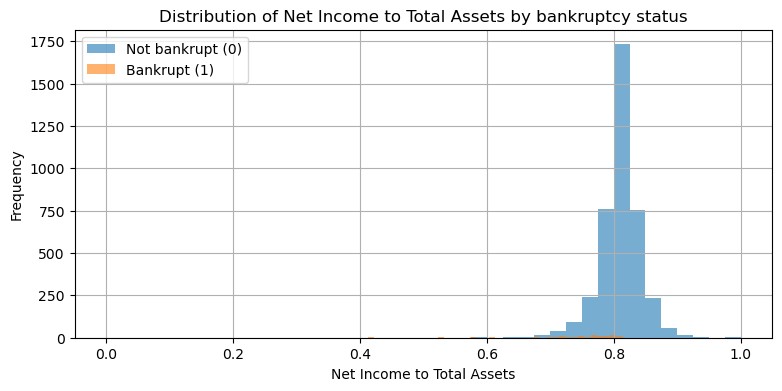

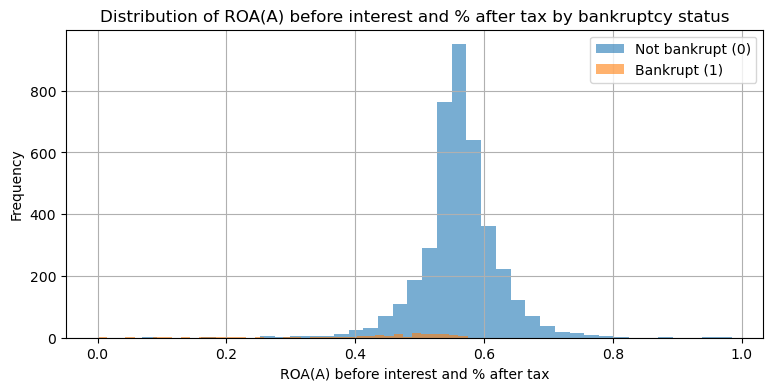

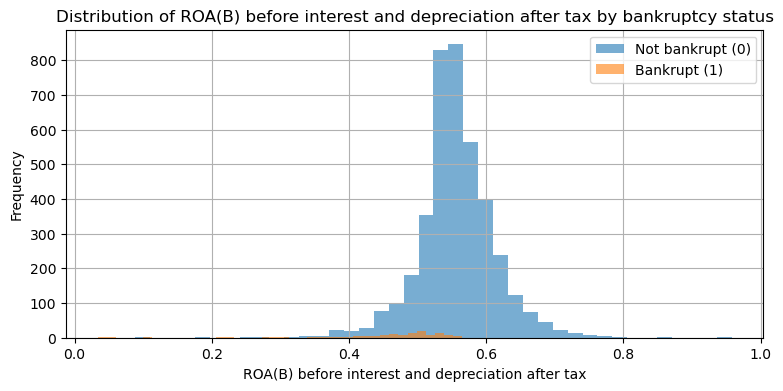

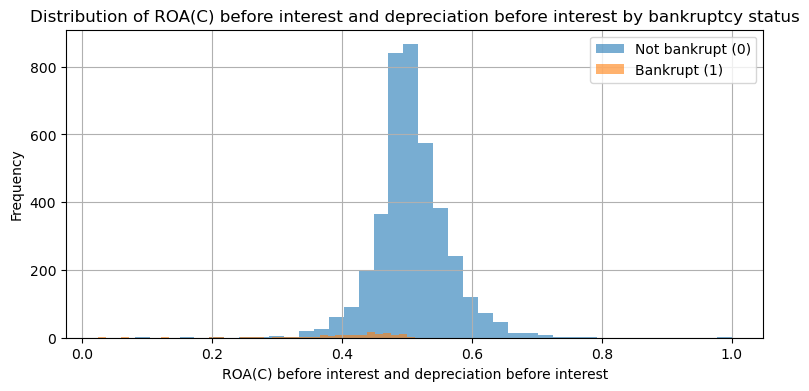

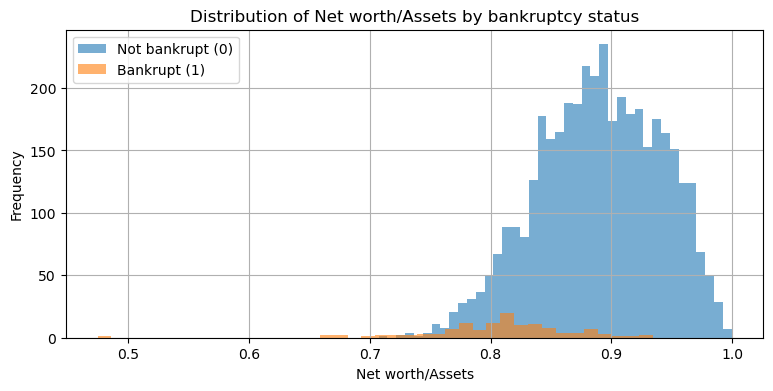

In [225]:
from pathlib import Path
import re
import matplotlib.pyplot as plt

save_dir = Path(r"C:\Users\alnur\Desktop\My life\ML Engineer\eda_plots")
save_dir.mkdir(parents=True, exist_ok=True)

for i, feature in enumerate(top_features_for_eda, start=1):
    plt.figure(figsize=(9, 4))

    plt.hist(X.loc[y == 0, feature], bins=40, alpha=0.6, label="Not bankrupt (0)")
    plt.hist(X.loc[y == 1, feature], bins=40, alpha=0.6, label="Bankrupt (1)")

    plt.title(f"Distribution of {feature} by bankruptcy status")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()

    safe_feature = re.sub(r'[\\/*?:"<>|%()]', "_", feature)
    file_path = save_dir / f"{i:02d}_{safe_feature}.png"

    plt.savefig(file_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

### 4. Modelling 

#### 4.1 Train-validation-test split 

In [226]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size = 0.20,
    stratify = y,
    random_state=RANDOM_STATE
)

### first split: hold out final test set

In [227]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full,
    test_size = 0.25,
    stratify = y_train_full,
    random_state = RANDOM_STATE
)

### second split: validation set creation from training data

In [228]:
X_train.shape

(2454, 94)

In [229]:
X_valid.shape

(818, 94)

In [230]:
X_test.shape

(819, 94)

#### 4.2 Dummy baseline to show why accuracy alone is misleading

In [231]:
dummy = DummyClassifier(strategy = "most_frequent")
dummy.fit(X_train, y_train)

,strategy,'most_frequent'
,random_state,None
,constant,None


In [232]:
dummy_pred = dummy.predict(X_valid)
dummy_prob = np.zeros_like(y_valid, dtype=float)  # all predicted as class 0

print("Accuracy:", accuracy_score(y_valid, dummy_pred))
print("Recall:", recall_score(y_valid, dummy_pred, zero_division = 0))
print("F1:", f1_score(y_valid, dummy_pred, zero_division = 0))

Accuracy: 0.969437652811736
Recall: 0.0
F1: 0.0


In [233]:
### note: very high accuracy still can be bad, cuz positive class (1) is kinda rare

#### 4.3 Functions for evaluations

In [234]:
def evaluate_predictions(y_true, y_prob, threshold=0.50):
    y_pred = (y_prob >= threshold).astype(int)
    
    results = {
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "Average_Precision": average_precision_score(y_true, y_prob)
    }
    return pd.DataFrame([results]), y_pred

In [235]:
def plot_roc_pr(y_true, y_prob, model_name="Model"):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(fpr, tpr)
    axes[0].plot([0, 1], [0, 1], linestyle="--")
    axes[0].set_title(f"{model_name} - ROC Curve")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    
    axes[1].plot(recall, precision)
    axes[1].set_title(f"{model_name} - Precision-Recall Curve")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    
    plt.tight_layout()
    plt.show()

In [236]:
def find_best_threshold(y_true, y_prob):
    rows = []
    thresholds = np.arange(0.01, 0.99, 0.01)
    
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        rows.append({
            "threshold": t,
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)
        })
    
    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
    return threshold_df, best_row

In [237]:
def plot_threshold_search(threshold_df, model_name="Model"):
    plt.figure(figsize=(10, 5))
    plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
    plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
    plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
    plt.plot(threshold_df["threshold"], threshold_df["balanced_accuracy"], label="Balanced Accuracy")
    plt.title(f"{model_name} - Threshold tuning on validation set")
    plt.xlabel("Threshold")
    plt.ylabel("Metric value")
    plt.legend()
    plt.show()

#### 4.4 Logistic regression model (objective 1) 

In [238]:
log_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        solver="saga",
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

In [239]:
log_param_grid = {
    "model__penalty": ["l1", "l2"],
    "model__C": np.logspace(-3, 2, 12)
}

In [240]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [241]:
log_search = RandomizedSearchCV(
    estimator=log_pipeline,
    param_distributions=log_param_grid,
    n_iter=10,
    scoring="average_precision", 
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

In [242]:
log_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,Pipeline(step...ver='saga'))])
,param_distributions,"{'model__C': array([1.0000...00000000e+02]), 'model__penalty': ['l1', 'l2']}"
,n_iter,10
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [243]:
log_search.best_params_

{'model__penalty': 'l1', 'model__C': np.float64(0.0657933224657568)}

In [244]:
log_search.best_score_

np.float64(0.4472674171176802)

#### 4.5 XGBoost model - advanced model creation (objective 2) 

In [245]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [246]:
xgb_param_grid = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.08, 0.10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 2, 5]
}

In [247]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

In [248]:
xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [2, 3, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,20
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [249]:
xgb_search.best_params_

{'subsample': 1.0,
 'reg_lambda': 1,
 'reg_alpha': 1,
 'n_estimators': 400,
 'min_child_weight': 3,
 'max_depth': 2,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [250]:
xgb_search.best_score_

np.float64(0.43955257856811397)

#### 4.6 Comparing models on validation datasets

In [251]:
best_log_model = log_search.best_estimator_
best_xgb_model = xgb_search.best_estimator_

In [252]:
log_valid_prob = best_log_model.predict_proba(X_valid)[:, 1]
xgb_valid_prob = best_xgb_model.predict_proba(X_valid)[:, 1]

In [253]:
log_valid_metrics, _ = evaluate_predictions(y_valid, log_valid_prob, threshold=0.50)
xgb_valid_metrics, _ = evaluate_predictions(y_valid, xgb_valid_prob, threshold=0.50)

In [254]:
validation_comparison = pd.concat(
    [pd.DataFrame({"Model": ["Logistic Regression"]}).join(log_valid_metrics),
     pd.DataFrame({"Model": ["XGBoost"]}).join(xgb_valid_metrics)],
    ignore_index=True
)

In [255]:
validation_comparison.sort_values(by="F1", ascending=False)

,Model,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Average_Precision
1,XGBoost,0.5,0.935208,0.714779,0.230769,0.48,0.311688,0.911223,0.333433
0,Logistic Regression,0.5,0.865526,0.872535,0.170543,0.88,0.285714,0.929029,0.350619


In [305]:
validation_comparison.to_excel("comparison threshold.xlsx")

In [256]:
log_threshold_df, log_best_threshold_row = find_best_threshold(y_valid, log_valid_prob)
xgb_threshold_df, xgb_best_threshold_row = find_best_threshold(y_valid, xgb_valid_prob)

pd.DataFrame([log_best_threshold_row])

,threshold,accuracy,balanced_accuracy,precision,recall,f1
90,0.91,0.96577,0.691803,0.434783,0.4,0.416667


In [257]:
display(pd.DataFrame([xgb_best_threshold_row]))

,threshold,accuracy,balanced_accuracy,precision,recall,f1
71,0.72,0.954768,0.705498,0.323529,0.44,0.372881


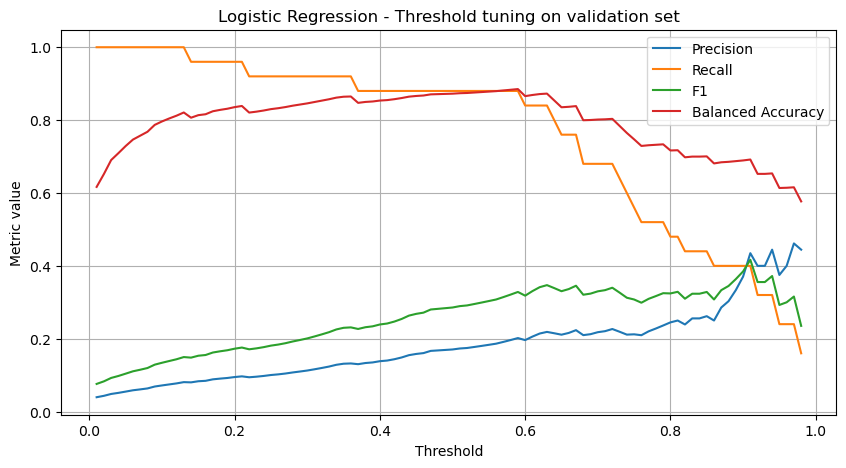

In [258]:
plot_threshold_search(log_threshold_df, "Logistic Regression")

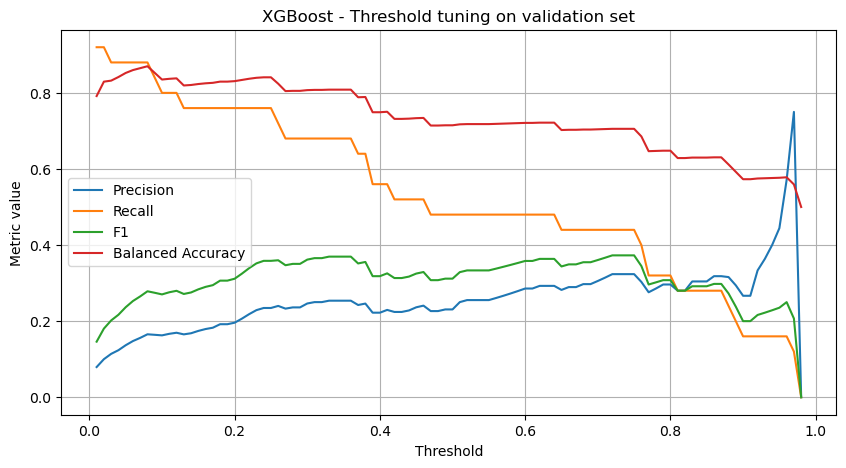

In [259]:
plot_threshold_search(xgb_threshold_df, "XGBoost")

In [260]:
best_log_threshold = float(log_best_threshold_row["threshold"])
best_xgb_threshold = float(xgb_best_threshold_row["threshold"])

print(best_log_threshold, best_xgb_threshold)

0.91 0.72


#### 4.8 Validation confusion matrices / classification report

In [261]:
_, log_valid_pred = evaluate_predictions(y_valid, log_valid_prob, threshold=best_log_threshold)
_, xgb_valid_pred = evaluate_predictions(y_valid, xgb_valid_prob, threshold=best_xgb_threshold)

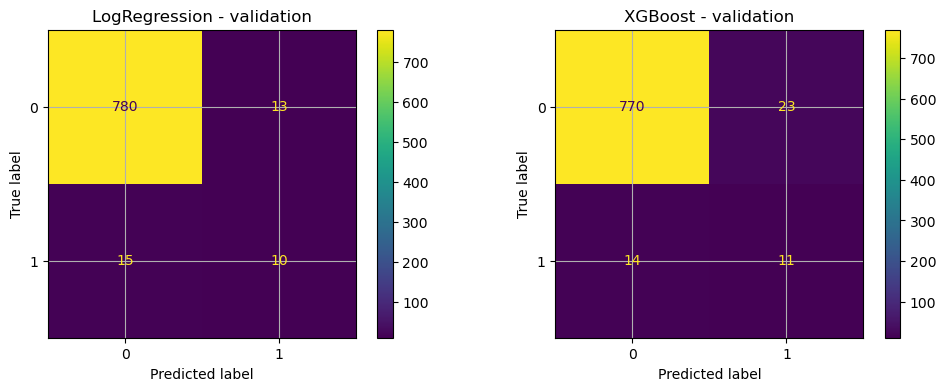

In [262]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_valid, log_valid_pred, ax=axes[0], values_format="d"
)
axes[0].set_title("LogRegression - validation")

ConfusionMatrixDisplay.from_predictions(
    y_valid, xgb_valid_pred, ax=axes[1], values_format="d"
)
axes[1].set_title("XGBoost - validation")

plt.show()

In [263]:
print(classification_report(y_valid, log_valid_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9811    0.9836    0.9824       793
           1     0.4348    0.4000    0.4167        25

    accuracy                         0.9658       818
   macro avg     0.7080    0.6918    0.6995       818
weighted avg     0.9644    0.9658    0.9651       818



In [264]:
print(classification_report(y_valid, xgb_valid_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9821    0.9710    0.9765       793
           1     0.3235    0.4400    0.3729        25

    accuracy                         0.9548       818
   macro avg     0.6528    0.7055    0.6747       818
weighted avg     0.9620    0.9548    0.9581       818



#### 4.9 Refit best models on train + validation, then test

In [265]:
best_log_model.fit(X_train_full, y_train_full)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [266]:
best_xgb_model.fit(X_train_full, y_train_full)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [267]:
log_test_prob = best_log_model.predict_proba(X_test)[:, 1]

In [268]:
xgb_test_prob = best_xgb_model.predict_proba(X_test)[:, 1]

In [269]:
log_test_metrics, log_test_pred = evaluate_predictions(y_test, log_test_prob, threshold=best_log_threshold)

In [270]:
xgb_test_metrics, xgb_test_pred = evaluate_predictions(y_test, xgb_test_prob, threshold=best_xgb_threshold)

In [271]:
test_comparison = pd.concat(
    [pd.DataFrame({"Model": ["Logistic Regression"]}).join(log_test_metrics),
     pd.DataFrame({"Model": ["XGBoost"]}).join(xgb_test_metrics)],
    ignore_index=True
)

In [272]:
test_comparison.sort_values(by="F1", ascending=False)

,Model,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Average_Precision
1,XGBoost,0.72,0.96337,0.748665,0.419355,0.52,0.464286,0.946801,0.478604
0,Logistic Regression,0.91,0.96337,0.690554,0.400000,0.40,0.400000,0.929521,0.440104


In [306]:
test_comparison.to_excel("test comparison.xlsx")

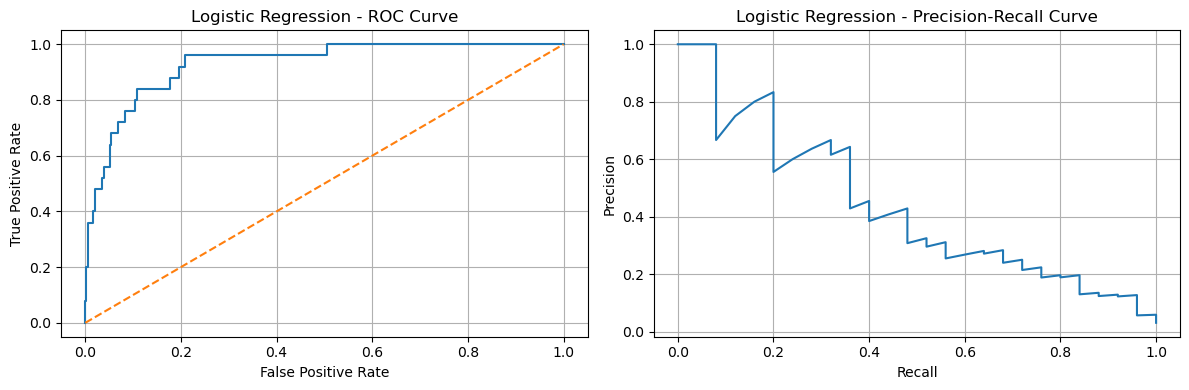

In [273]:
plot_roc_pr(y_test, log_test_prob, model_name ="Logistic Regression")

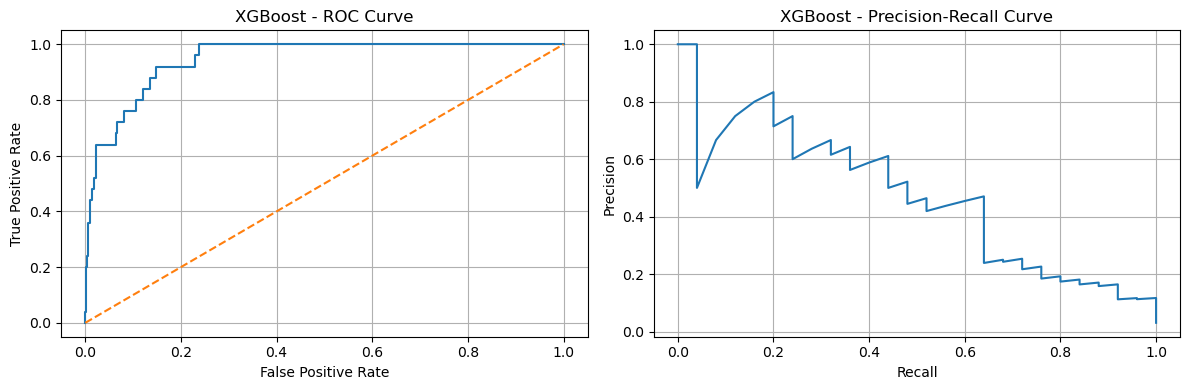

In [274]:
plot_roc_pr(y_test, xgb_test_prob, model_name = "XGBoost")

#### 4.10 Final test confusion matrices

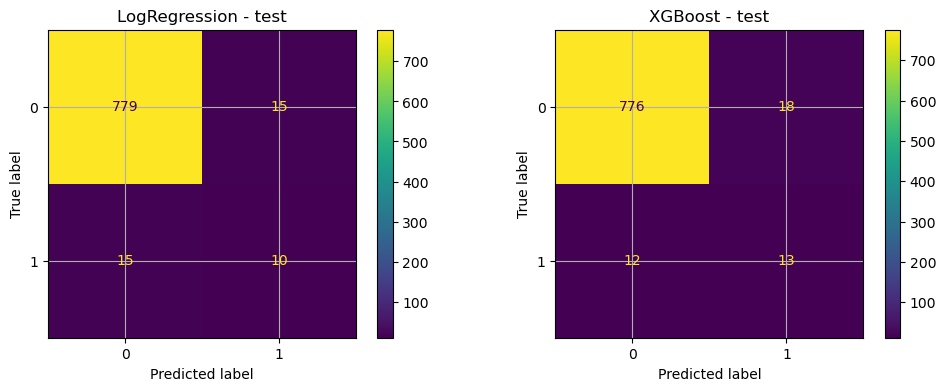

<Figure size 900x500 with 0 Axes>

In [309]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, log_test_pred, ax=axes[0], values_format="d"
)
axes[0].set_title("LogRegression - test")

ConfusionMatrixDisplay.from_predictions(
    y_test, xgb_test_pred, ax=axes[1], values_format="d"
)
axes[1].set_title("XGBoost - test")
plt.show()
plt.savefig("confusion.png")

In [276]:
print(classification_report(y_test, log_test_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9811    0.9811    0.9811       794
           1     0.4000    0.4000    0.4000        25

    accuracy                         0.9634       819
   macro avg     0.6906    0.6906    0.6906       819
weighted avg     0.9634    0.9634    0.9634       819



In [277]:
print(classification_report(y_test, xgb_test_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9848    0.9773    0.9810       794
           1     0.4194    0.5200    0.4643        25

    accuracy                         0.9634       819
   macro avg     0.7021    0.7487    0.7227       819
weighted avg     0.9675    0.9634    0.9653       819



#### 4.11 Probability calibration for the final XGBoost model

In [278]:
calibrated_xgb_valid = CalibratedClassifierCV(
    estimator=clone(best_xgb_model),
    method="isotonic",
    cv=5
)

In [279]:
calibrated_xgb_valid.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,method,'isotonic'
,cv,5
,n_jobs,None
,ensemble,'auto'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


In [280]:
cal_xgb_valid_prob = calibrated_xgb_valid.predict_proba(X_valid)[:, 1]
cal_threshold_df, cal_best_threshold_row = find_best_threshold(y_valid, cal_xgb_valid_prob)

print("Best threshold for calibrated XGBoost:")
pd.DataFrame([cal_best_threshold_row])

Best threshold for calibrated XGBoost:


,threshold,accuracy,balanced_accuracy,precision,recall,f1
16,0.17,0.938875,0.794149,0.280702,0.64,0.390244


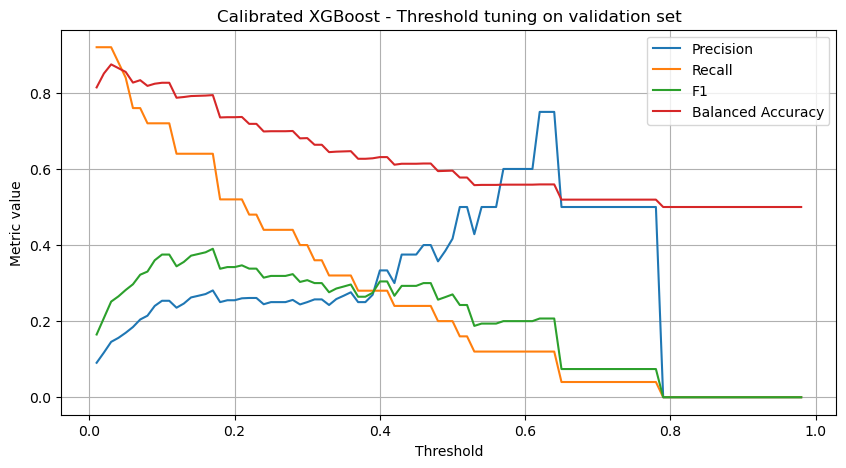

In [281]:
best_cal_threshold = float(cal_best_threshold_row["threshold"])
plot_threshold_search(cal_threshold_df, "Calibrated XGBoost")

In [282]:
calibrated_xgb_final = CalibratedClassifierCV(
    estimator=clone(best_xgb_model),
    method="isotonic",
    cv=5
)

In [283]:
calibrated_xgb_final.fit(X_train_full, y_train_full)

,estimator,"XGBClassifier...ree=None, ...)"
,method,'isotonic'
,cv,5
,n_jobs,None
,ensemble,'auto'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


In [284]:
cal_xgb_test_prob = calibrated_xgb_final.predict_proba(X_test)[:, 1]
cal_xgb_test_metrics, cal_xgb_test_pred = evaluate_predictions(
    y_test, cal_xgb_test_prob, threshold=best_cal_threshold
)

In [285]:
cal_xgb_test_metrics

,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Average_Precision
0,0.17,0.952381,0.762368,0.333333,0.56,0.41791,0.953224,0.524239


In [286]:
print(classification_report(y_test, cal_xgb_test_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9858    0.9647    0.9752       794
           1     0.3333    0.5600    0.4179        25

    accuracy                         0.9524       819
   macro avg     0.6596    0.7624    0.6965       819
weighted avg     0.9659    0.9524    0.9582       819



#### 4.12  Comparison of all models

In [287]:
final_comparison = pd.concat(
    [pd.DataFrame({"Model": ["Logistic Regression"]}).join(log_test_metrics),
     pd.DataFrame({"Model": ["XGBoost"]}).join(xgb_test_metrics),
     pd.DataFrame({"Model": ["Calibrated XGBoost"]}).join(cal_xgb_test_metrics)],
    ignore_index=True
)

In [288]:
final_comparison.sort_values(by="F1", ascending=False)

,Model,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Average_Precision
1,XGBoost,0.72,0.963370,0.748665,0.419355,0.52,0.464286,0.946801,0.478604
2,Calibrated XGBoost,0.17,0.952381,0.762368,0.333333,0.56,0.417910,0.953224,0.524239
0,Logistic Regression,0.91,0.963370,0.690554,0.400000,0.40,0.400000,0.929521,0.440104


In [311]:
final_comparison.to_excel("final comparison.xlsx")

### 5. Evaluation of models

#### 5.1 LogRegression coefficient interpretation

In [289]:
log_model_step = best_log_model.named_steps["model"]
log_feature_names = X_train_full.columns

In [290]:
log_coef_df = pd.DataFrame({
    "Feature": log_feature_names,
    "Coefficient": log_model_step.coef_[0]
})

In [291]:
#### odds ratio based on scaled features: one standard deviation increase in a feature changes the odds by exp(coef)
log_coef_df["Odds_Ratio"] = np.exp(log_coef_df["Coefficient"])
log_coef_df["Abs_Coefficient"] = log_coef_df["Coefficient"].abs()

In [292]:
log_coef_df = log_coef_df.sort_values(by = "Abs_Coefficient", ascending = False)

In [293]:
print("Top positive coefficients (ones that increase bankruptcy odds)")
log_coef_df[log_coef_df["Coefficient"] > 0].head(10)

Top positive coefficients (ones that increase bankruptcy odds)


,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
36,Debt ratio %,0.701569,2.016914,0.701569
70,Current Asset Turnover Rate,0.276185,1.318092,0.276185
50,Revenue per person,0.134148,1.143562,0.134148
23,Realized Sales Gross Profit Growth Rate,0.129833,1.138638,0.129833
59,Current Liability to Assets,0.128859,1.137530,0.128859
54,Quick Assets/Total Assets,0.113680,1.120394,0.113680
87,No-credit Interval,0.106459,1.112332,0.106459
10,Operating Expense Rate,0.095732,1.100464,0.095732
11,Research and development expense rate,0.094734,1.099366,0.094734
28,Total Asset Growth Rate,0.052539,1.053943,0.052539


In [294]:
print("Top negative coefficients (ones that reduce bankruptcy odds)")
log_coef_df[log_coef_df["Coefficient"] < 0].head(10)

Top negative coefficients (ones that reduce bankruptcy odds)


,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
44,Total Asset Turnover,-1.041379,0.352968,1.041379
18,Persistent EPS in the Last Four Seasons,-0.765790,0.464967,0.765790
0,ROA(C) before interest and depreciation before...,-0.736262,0.478901,0.736262
37,Net worth/Assets,-0.701569,0.495807,0.701569
56,Cash/Total Assets,-0.691762,0.500693,0.691762
45,Accounts Receivable Turnover,-0.253580,0.776017,0.253580
73,Cash Turnover Rate,-0.167639,0.845659,0.167639
51,Operating profit per person,-0.143099,0.866668,0.143099
43,Inventory and accounts receivable/Net value,-0.119154,0.887671,0.119154
66,Long-term Liability to Current Assets,-0.090089,0.913850,0.090089


#### 5.2 Feature importance for XGBoost model

In [295]:
xgb_importance = pd.DataFrame({"Feature": X_train_full.columns, "Importance": best_xgb_model.feature_importances_}).sort_values(by = "Importance", ascending=False)
xgb_importance

,Feature,Importance
18,Persistent EPS in the Last Four Seasons,0.110936
39,Borrowing dependency,0.094779
0,ROA(C) before interest and depreciation before...,0.062407
85,Net Income to Total Assets,0.060989
36,Debt ratio %,0.053811
9,Continuous interest rate (after tax),0.044896
35,Total debt/Total net worth,0.043671
34,Interest Expense Ratio,0.041792
33,Quick Ratio,0.041229
15,Net Value Per Share (B),0.029053


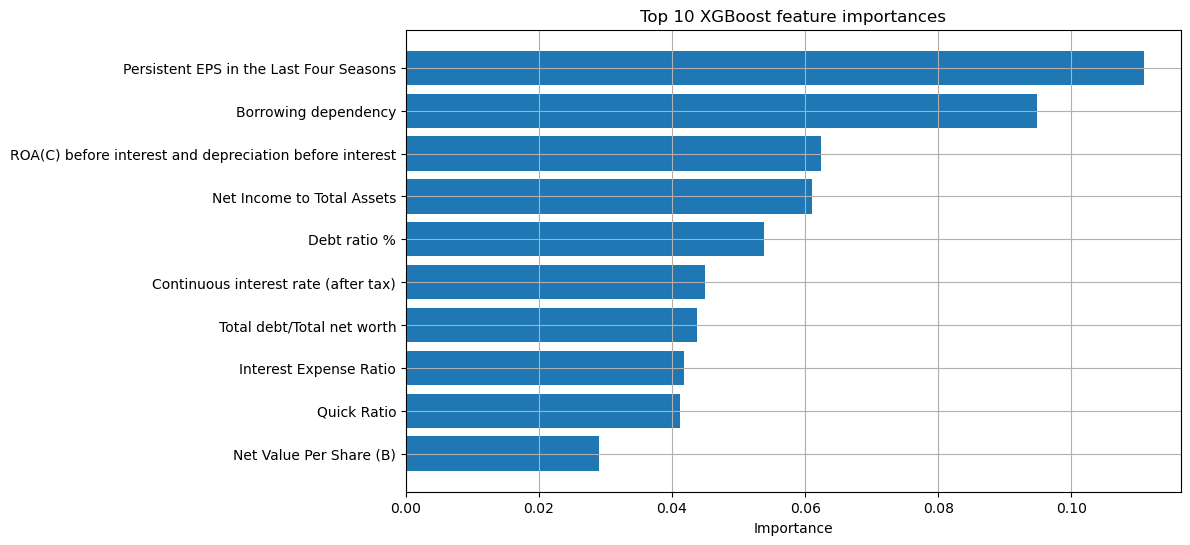

<Figure size 900x500 with 0 Axes>

In [312]:
plt.figure(figsize = (10, 6))
plt.barh(
    xgb_importance.head(10)["Feature"][::-1],
    xgb_importance.head(10)["Importance"][::-1]
)
plt.title("Top 10 XGBoost feature importances")
plt.xlabel("Importance")
plt.show()
plt.savefig("top10.png")

#### 5.3 SHAP global explanation (contribution of each vairable to the model's predictive power

In [297]:
explainer = shap.Explainer(best_xgb_model, X_train_full)
shap_values = explainer(X_train_full)

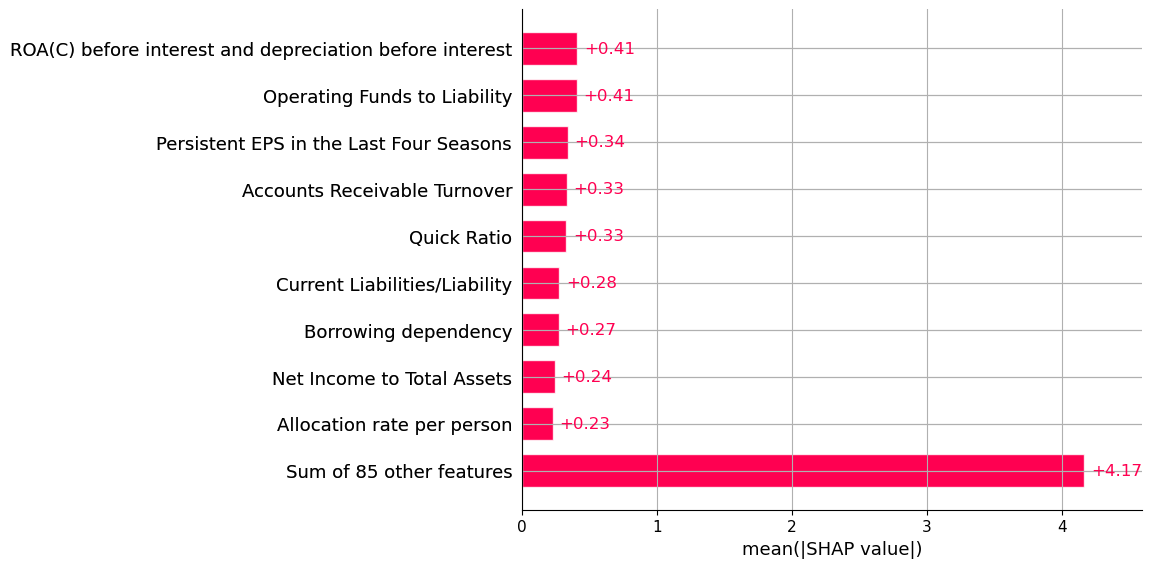

In [298]:
shap.plots.bar(shap_values, max_display=10)

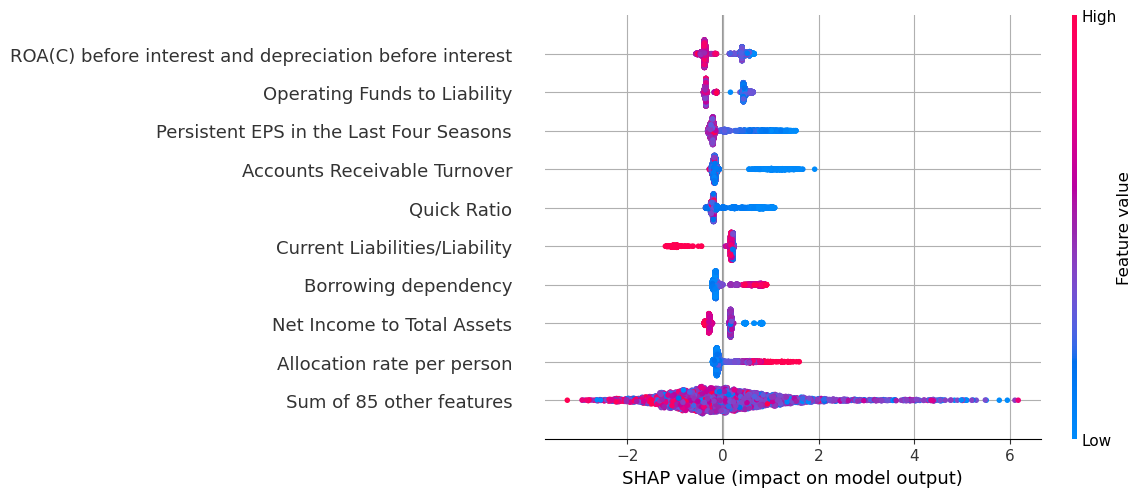

In [299]:
shap.plots.beeswarm(shap_values, max_display = 10)

#### 5.4 SHAP dependence plots for the most crucial features

In [300]:
mean_abs_shap = np.abs(shap_values.values).mean(axis = 0)
shap_importance_df = pd.DataFrame({"Feature": X_train_full.columns, "Mean_Abs_SHAP": mean_abs_shap }).sort_values(by = "Mean_Abs_SHAP", ascending = False)

In [301]:
top_shap_features = shap_importance_df["Feature"].head(3).tolist()
top_shap_features

['ROA(C) before interest and depreciation before interest',
 'Operating Funds to Liability',
 'Persistent EPS in the Last Four Seasons']

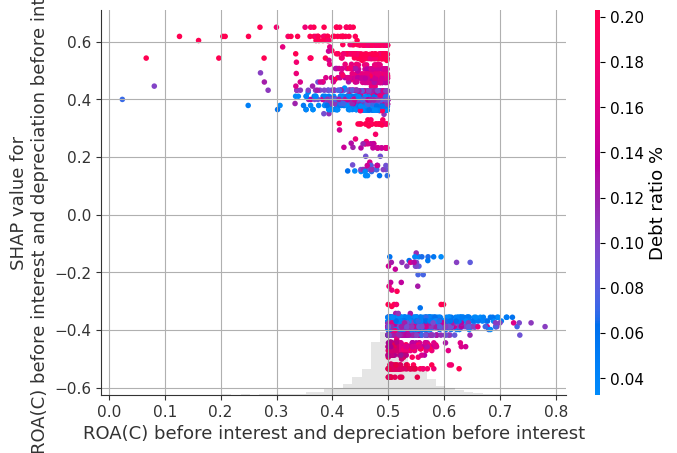

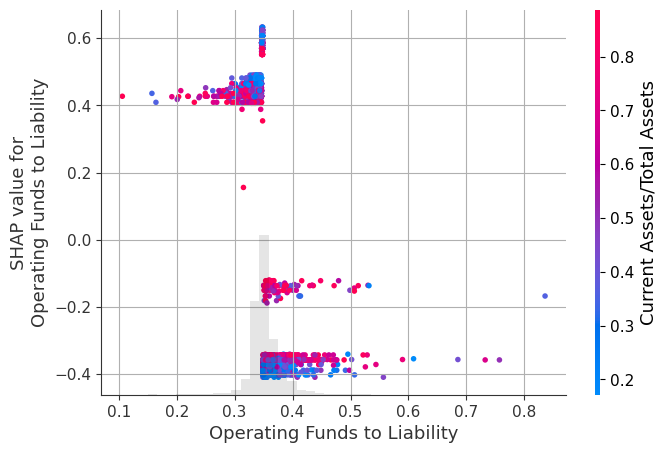

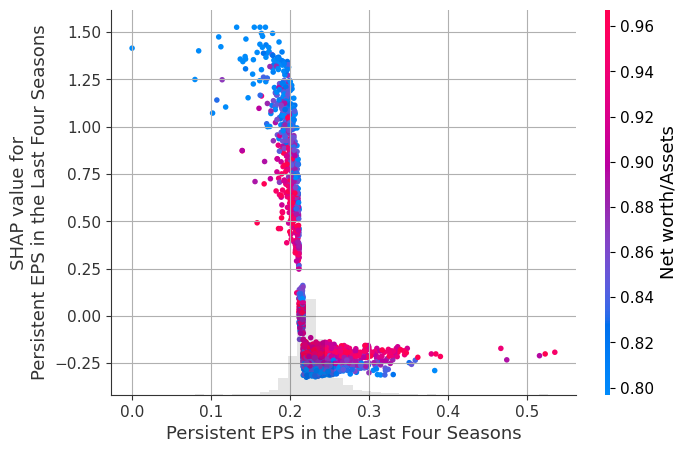

In [302]:
for feature in top_shap_features:
    shap.plots.scatter(shap_values[:, feature], color=shap_values)

### 6. Conclusions

In [303]:
top_shap_table = shap_importance_df.head(10).copy()
top_shap_table["Rank"] = range(1, len(top_shap_table) + 1)
top_shap_table[["Rank", "Feature", "Mean_Abs_SHAP"]]

,Rank,Feature,Mean_Abs_SHAP
0,1,ROA(C) before interest and depreciation before...,0.411204
60,2,Operating Funds to Liability,0.407591
18,3,Persistent EPS in the Last Four Seasons,0.340724
45,4,Accounts Receivable Turnover,0.334708
33,5,Quick Ratio,0.329250
63,6,Current Liabilities/Liability,0.278034
39,7,Borrowing dependency,0.273688
85,8,Net Income to Total Assets,0.244477
52,9,Allocation rate per person,0.229348
82,10,Cash Flow to Equity,0.197274


In [304]:
best_final_model = final_comparison.sort_values(by = "F1", ascending=False).iloc[0]
best_final_model

Model                 XGBoost
Threshold                0.72
Accuracy              0.96337
Balanced_Accuracy    0.748665
Precision            0.419355
Recall                   0.52
F1                   0.464286
ROC_AUC              0.946801
Average_Precision    0.478604
Name: 1, dtype: object

### Brief concl:
* The dataset is highly imbalanced, so accuracy alone is not sufficient
* Logistic regression is useful as a benchmark and for interpretable directional effects
* XGBoost model because it captures nonlinear patterns better (highest F1)
* SHAP shows which financial ratios matter most and how they influence bankruptcy risk.